In [1]:
import copy
import pathlib
from typing import Optional, Set, Mapping, Sequence
import os.path
import math
import functools

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from matplotlib import pyplot as plt
from scipy import stats
from statsmodels.stats import proportion

In [3]:
from drmdp import dataproc

In [4]:
import warnings  # To suppress some warnings

# Suppress the specific FutureWarning
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

In [5]:
files = tf.io.gfile.glob(
    f"{pathlib.Path.home()}/fs/drmdp/workflows/controljob/agg/1772983724/1772992432/metrics/*.parquet"
)

In [6]:
df_metrics = dataproc.read_data(files, reader="pd")

In [7]:
df_metrics

,episode,exp_id,meta,returns,steps,metrics,method
0,390,1772983724-0067d357-Finite-CC-ShuntDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[11425.588676040405, 11855.309485639467, 11906...","[10000, 10000, 854, 10000, 10000, 5985, 6795, ...","{'returns': {'mean': 11501.326835673426, 'std'...",FR
3,390,1772983724-0519c138-Finite-CC-PermExDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[11738.834433644248, 10928.992765198936, 11132...","[6572, 4215, 3379, 7948, 10000, 6324, 3098, 10...","{'returns': {'mean': 10026.432969495087, 'std'...",BLADE-TD
4,390,1772983724-0561605a-Finite-SC-PermExDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[1050.724894112128, 820.7110265811008, 939.221...","[328, 1526, 455, 636, 361, 1179, 246, 266, 185...","{'returns': {'mean': 1021.7995423610597, 'std'...",IMR
7,390,1772983724-0c1a6486-Finite-TC-PermExDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[6786.188323206214, 7923.673874855165, 7579.95...","[5039, 3761, 53, 7662, 10000, 138, 10000, 1314...","{'returns': {'mean': 7116.390955422966, 'std':...",IMR
8,390,1772983724-0ee19c07-Finite-SC-ShuntDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[224.84979924568395, 1343.1712552824158, 277.9...","[3491, 243, 36, 8, 11, 1541, 1554, 7, 41, 7, 2...","{'returns': {'mean': 578.71541393419, 'std': 5...",DMR
...,...,...,...,...,...,...,...
245,210,1772983724-f768ece2-Finite-CC-PermExDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[129.2177113574301, 141.91227011151037, 175.87...","[101, 77, 36, 117, 28, 31, 11, 29, 77, 24, 237...","{'returns': {'mean': 146.78908431076604, 'std'...",OP-A
248,210,1772983724-fa9e2560-Finite-TC-ShuntDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[2393.457856081534, 2075.1664275337844, 2451.7...","[9, 102, 8, 14, 8, 108, 6579, 7, 7, 2964, 1761...","{'returns': {'mean': 1463.7337672035012, 'std'...",DMR
249,210,1772983724-fcaef02e-Finite-TC-PermExDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[7978.698568076154, 8269.575630667052, 7661.57...","[8582, 197, 6783, 3370, 10000, 3020, 1954, 334...","{'returns': {'mean': 7074.941044575697, 'std':...",IMR
250,210,1772983724-fe0e2030-Finite-SC-ShuntDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[1178.4924371012733, 1210.7621488027414, 1170....","[222, 590, 664, 638, 548, 4592, 388, 1108, 108...","{'returns': {'mean': 1335.9234477657872, 'std'...",BLADE-TD


In [8]:
df_metrics.iloc[0]["meta"]

{'context': {'dummy': 0},
 'exp_id': '1772983724-0067d357-Finite-CC-ShuntDc-v0',
 'export_model': True,
 'instance_id': 0,
 'run_config': {'episodes_per_run': 500,
  'log_episode_frequency': 10,
  'num_runs': 20,
  'output_dir': 'gs://mo-hendrix-ml-workflows-storage/drmdp/workflows/controljob/logs/1772983724/1772983724-0067d357-Finite-CC-ShuntDc-v0/run_0/identity/cfc91fc9',
  'use_seed': True},
 'env_spec': {'args': {'constraint_violation_reward': -10.0,
   'emit_state': False,
   'max_episode_steps': 10000,
   'penalty_gamma': 1.0,
   'reward_fn': 'pos-enf'},
  'feats_spec': array([{'args': {'tiling_dim': 3.0}, 'name': 'tile-observation-action-ft'}],
        dtype=object),
  'name': 'Finite-CC-ShuntDc-v0'},
 'epochs': 1,
 'problem_spec': {'delay_config': None,
  'epsilon': 0.1,
  'gamma': 0.99,
  'learning_rate_config': {'args': {'initial_lr': 0.01}, 'name': 'constant'},
  'policy_type': 'markovian',
  'reward_mapper': {'args': None, 'name': 'identity'}},
 'reward_mapper': 'FR',
 'pol

In [9]:
envs = dataproc.get_distinct_envs(df_metrics)

In [10]:
for env_name, args in envs.items():
    print(env_name, args)

Finite-CC-ShuntDc-v0 {'constraint_violation_reward': -10.0, 'emit_state': False, 'max_episode_steps': 10000, 'penalty_gamma': 1.0, 'reward_fn': 'pos-enf'}
Finite-CC-PermExDc-v0 {'constraint_violation_reward': -10.0, 'emit_state': False, 'max_episode_steps': 10000, 'penalty_gamma': 1.0, 'reward_fn': 'pos-enf'}
Finite-SC-PermExDc-v0 {'constraint_violation_reward': -10.0, 'emit_state': False, 'max_episode_steps': 10000, 'penalty_gamma': 1.0, 'reward_fn': 'pos-enf'}
Finite-TC-PermExDc-v0 {'constraint_violation_reward': -10.0, 'emit_state': False, 'max_episode_steps': 10000, 'penalty_gamma': 1.0, 'reward_fn': 'pos-enf'}
Finite-SC-ShuntDc-v0 {'constraint_violation_reward': -10.0, 'emit_state': True, 'max_episode_steps': 10000, 'penalty_gamma': 1.0, 'reward_fn': 'pos-enf'}
Finite-TC-ShuntDc-v0 {'constraint_violation_reward': -10.0, 'emit_state': True, 'max_episode_steps': 10000, 'penalty_gamma': 1.0, 'reward_fn': 'pos-enf'}


In [11]:
df_metrics

,episode,exp_id,meta,returns,steps,metrics,method
0,390,1772983724-0067d357-Finite-CC-ShuntDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[11425.588676040405, 11855.309485639467, 11906...","[10000, 10000, 854, 10000, 10000, 5985, 6795, ...","{'returns': {'mean': 11501.326835673426, 'std'...",FR
3,390,1772983724-0519c138-Finite-CC-PermExDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[11738.834433644248, 10928.992765198936, 11132...","[6572, 4215, 3379, 7948, 10000, 6324, 3098, 10...","{'returns': {'mean': 10026.432969495087, 'std'...",BLADE-TD
4,390,1772983724-0561605a-Finite-SC-PermExDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[1050.724894112128, 820.7110265811008, 939.221...","[328, 1526, 455, 636, 361, 1179, 246, 266, 185...","{'returns': {'mean': 1021.7995423610597, 'std'...",IMR
7,390,1772983724-0c1a6486-Finite-TC-PermExDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[6786.188323206214, 7923.673874855165, 7579.95...","[5039, 3761, 53, 7662, 10000, 138, 10000, 1314...","{'returns': {'mean': 7116.390955422966, 'std':...",IMR
8,390,1772983724-0ee19c07-Finite-SC-ShuntDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[224.84979924568395, 1343.1712552824158, 277.9...","[3491, 243, 36, 8, 11, 1541, 1554, 7, 41, 7, 2...","{'returns': {'mean': 578.71541393419, 'std': 5...",DMR
...,...,...,...,...,...,...,...
245,210,1772983724-f768ece2-Finite-CC-PermExDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[129.2177113574301, 141.91227011151037, 175.87...","[101, 77, 36, 117, 28, 31, 11, 29, 77, 24, 237...","{'returns': {'mean': 146.78908431076604, 'std'...",OP-A
248,210,1772983724-fa9e2560-Finite-TC-ShuntDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[2393.457856081534, 2075.1664275337844, 2451.7...","[9, 102, 8, 14, 8, 108, 6579, 7, 7, 2964, 1761...","{'returns': {'mean': 1463.7337672035012, 'std'...",DMR
249,210,1772983724-fcaef02e-Finite-TC-PermExDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[7978.698568076154, 8269.575630667052, 7661.57...","[8582, 197, 6783, 3370, 10000, 3020, 1954, 334...","{'returns': {'mean': 7074.941044575697, 'std':...",IMR
250,210,1772983724-fe0e2030-Finite-SC-ShuntDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[1178.4924371012733, 1210.7621488027414, 1170....","[222, 590, 664, 638, 548, 4592, 388, 1108, 108...","{'returns': {'mean': 1335.9234477657872, 'std'...",BLADE-TD


In [12]:
sorted(df_metrics["meta"].apply(lambda meta: meta["env_spec"]["name"]).unique())

['Finite-CC-PermExDc-v0',
 'Finite-CC-ShuntDc-v0',
 'Finite-SC-PermExDc-v0',
 'Finite-SC-ShuntDc-v0',
 'Finite-TC-PermExDc-v0',
 'Finite-TC-ShuntDc-v0']

## Comparison: T-Test

In [13]:
PVALUE_THRESHOLD = 0.05

In [14]:
def parse_delay_config(df_input: pd.DataFrame):
    df = copy.deepcopy(df_input)

    def parse_mu(delay_config):
        if delay_config is None:
            return None
        args = delay_config["args"]
        try:
            return args["delay"]
        except KeyError:
            return args["lam"]
        except KeyError as exc:
            raise ValueError(f"Unknown delay config {args}") from exc

    df["delay_type"] = df["delay_config"].apply(lambda dc: dc["name"] if dc else None)
    df["delay_mu"] = df["delay_config"].apply(parse_mu)
    del df["delay_config"]
    return df

In [15]:
def max_episode_filter(df_input):
    env_spec = df_input["meta"].apply(lambda meta: meta["env_spec"])
    env_name = env_spec.apply(lambda spec: spec["name"])
    envs = env_name.unique()
    dfs = []
    for env in envs:
        df_slice = df_input[(env_name == env)]
        df_slice = df_slice[df_slice["episode"] == df_slice["episode"].max()]
        dfs.append(copy.deepcopy(df_slice))
    return pd.concat(dfs)

In [16]:
def filter_envs(df_input, envs: Set[str]):
    env_spec = df_input["meta"].apply(lambda meta: meta["env_spec"])
    mask = env_spec.apply(lambda spec: spec["name"] in envs)
    return copy.deepcopy(df_input[mask])

In [17]:
def parse_specs(xs, scope: str, col: str):
    if isinstance(xs, Mapping):
        return xs[col]
    values = tuple(el[col] for el in xs)
    if scope == "feats":
        if col == "name":
            return dataproc.FEAT_PROCS[values[0]]
        return values[0]
    return values

In [18]:
def extract_salient_meta_fields(df_data: pd.DataFrame):
    df_raw = copy.deepcopy(df_data)
    specs = {
        "env": df_raw["meta"].apply(lambda meta: meta["env_spec"]),
        "feats": df_raw["meta"].apply(lambda meta: meta["env_spec"]["feats_spec"]),
    }
    for prefix, col_fam in specs.items():
        for col in ("name", "args"):
            df_raw[f"{prefix}_{col}"] = col_fam.apply(
                functools.partial(parse_specs, scope=prefix, col=col)
        )
    for key in (
        "delay_config",
        "gamma",
    ):
        df_raw[key] = df_raw["meta"].apply(lambda meta: meta["problem_spec"][key])
    return parse_delay_config(df_raw)

In [19]:
def mannwhitney_less_than_test(
    candidate_xs, reference_ys, alpha: float = PVALUE_THRESHOLD
):
    """
    Use for
     - No assumption of Normality
     - Seeds are different for each algorithm
    """
    # stats.ttest_ind
    xs_stat, test_pvalue = stats.mannwhitneyu(
        candidate_xs, reference_ys, alternative="less"
    )
    if test_pvalue < alpha:
        outcome = "Reject H0 (Less than)"
    else:
        outcome = "Fail to reject H0 (Similar)"
    return outcome

In [20]:
def wilcoxon_less_than_test(candidate_xs, reference_ys, alpha=PVALUE_THRESHOLD):
    """
    Use for
     - No assumptions of Normality
     - Used the same seed for each algorithm
    """
    differences = candidate_xs - reference_ys

    non_zero_diffs = differences[differences != 0]
    if len(non_zero_diffs) < 10:
        print(f"Warning: Only {len(non_zero_diffs)} non-zero differences found.")
        print("The test may have low power. This is unusual for episodic returns.")

    # The 'zero_method' handles how to treat zero-differences.
    # 'pratt' is a good default (includes them in ranking),
    # 'wilcox' (default) discards them. Let's use 'pratt'.
    stat, test_pvalue = stats.wilcoxon(
        differences, alternative="less", zero_method="pratt"
    )
    if test_pvalue < alpha:
        outcome = "Reject H0 (Less than)"
    else:
        outcome = "Fail to reject H0 (Similar)"
    return outcome

In [21]:
def ztest(left_pos, left_neg, right_pos, right_neg, alpha=PVALUE_THRESHOLD):
    zstat, test_pvalue = proportion.proportions_ztest(
        count=left_pos,
        nobs=left_pos + left_neg,
        value=right_pos / (right_pos + right_neg),
    )
    if test_pvalue < alpha:
        outcome = "Reject H0 (Different)"
    else:
        outcome = "Fail to reject H0 (Similar)"
    return outcome

In [22]:
def sample_stat_test_method_comparison(df_data, episode: Optional[int] = None):
    if episode is not None:
        df_result = copy.deepcopy(df_data[df_data["episode"] == episode])
    else:
        df_result = max_episode_filter(df_data)

    df_result = extract_salient_meta_fields(df_result)

    # (env/level)  x (algorithm/algorithm_args) x reward period -> which method is the winner
    del df_result["meta"]
    del df_result["exp_id"]

    rows = []
    keys = ["env_name", "gamma", "delay_mu"]
    df_baseline = df_result[pd.isnull(df_result["delay_type"])]
    df_result = df_result[~pd.isnull(df_result["delay_type"])]

    baselines = {}
    for row in df_baseline.to_dict("records"):
        key = tuple(row[key] for key in keys[:-1])
        baselines[key] = row["returns"]

    rows = []
    for row in df_result.to_dict("records"):
        key = tuple([row[key] for key in keys[:-1]])
        full_reward_mean_return = baselines[key]

        test_result = mannwhitney_less_than_test(
            row["returns"], full_reward_mean_return
        )
        row["mannwhitney_less_than_test"] = test_result
        rows.append(row)
    df_test_result = pd.DataFrame(rows)

    # aggreate over algorithm args and reward periods
    agg_keys = ["method", "mannwhitney_less_than_test"]

    df_test_result_agg = (
        df_test_result[agg_keys].value_counts().reset_index().sort_values(agg_keys)
    )

    method_rows = (
        df_test_result_agg.pivot(
            index="method", columns="mannwhitney_less_than_test", values="count"
        )
        .reset_index()
        .to_dict("records")
    )
    df_test_result_agg = pd.DataFrame(method_rows)
    df_test_result_agg["Similarity Ratio"] = rations(df_test_result_agg)

    rows = []
    for left in method_rows:
        for right in method_rows:
            outcome = ztest(
                left_pos=left["Fail to reject H0 (Similar)"],
                left_neg=left["Reject H0 (Less than)"],
                right_pos=right["Fail to reject H0 (Similar)"],
                right_neg=right["Reject H0 (Less than)"],
            )
            row = {
                "left": left["method"],
                "right": right["method"],
                "outcome": outcome,
            }
            rows.append(row)
    df_conf = pd.DataFrame(rows)

    return {"sarsa": df_test_result}, {"sarsa": df_test_result_agg}, {"sarsa": df_conf}

In [23]:
def rations(df):
    df_raw = copy.deepcopy(df)
    df_raw = df_raw.fillna(0)
    return df_raw["Fail to reject H0 (Similar)"] / (
        df_raw["Fail to reject H0 (Similar)"] + df_raw["Reject H0 (Less than)"]
    )

### K=100

In [24]:
df_test_outcome_k100, df_test_agg_stat_k100, df_test_comparison_k100 = (
    sample_stat_test_method_comparison(df_metrics, episode=100)
)

In [25]:
df_test_outcome_k100["sarsa"]

,episode,returns,steps,metrics,method,env_name,env_args,feats_name,feats_args,gamma,delay_type,delay_mu,mannwhitney_less_than_test
0,100,"[11755.490187279465, 9363.929776503104, 11770....","[10000, 10000, 6227, 3909, 10000, 605, 2697, 2...","{'returns': {'mean': 8666.713494496305, 'std':...",BLADE-TD,Finite-CC-PermExDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",spliced-tiles,{'tiling_dim': 4.0},0.99,clipped-poisson,2.0,Fail to reject H0 (Similar)
1,100,"[1134.9304766088512, 41.73743560698605, 614.75...","[112, 2292, 220, 1233, 1548, 664, 1137, 156, 1...","{'returns': {'mean': 916.4509786630636, 'std':...",IMR,Finite-SC-PermExDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",spliced-tiles,{'tiling_dim': 3.0},0.99,clipped-poisson,4.0,Reject H0 (Less than)
2,100,"[5431.023779083984, 8871.835942418069, 8723.81...","[1542, 4796, 3540, 7471, 331, 1389, 1274, 1078...","{'returns': {'mean': 6603.018238864117, 'std':...",IMR,Finite-TC-PermExDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",tiles,{'tiling_dim': 3.0},0.99,clipped-poisson,8.0,Reject H0 (Less than)
3,100,"[3.119720947085701, 1742.3750296121527, 2.5815...","[13, 948, 8, 9, 7, 9, 107, 7, 8, 7, 153, 7, 8,...","{'returns': {'mean': 651.7824196913175, 'std':...",DMR,Finite-SC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",scale,None,1.00,clipped-poisson,2.0,Fail to reject H0 (Similar)
4,100,"[5.085824056915767, 4.526500956323786, 4.72800...","[8, 7, 9, 7, 7, 8, 7, 7, 7, 7, 7, 7, 7, 7, 145...","{'returns': {'mean': 1048.287667556289, 'std':...",DMR,Finite-TC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",scale,None,0.99,clipped-poisson,6.0,Fail to reject H0 (Similar)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,100,"[74.07296908687957, 84.43522074825303, 70.0362...","[86, 90, 113, 53, 82, 112, 75, 71, 185, 152, 6...","{'returns': {'mean': 85.47658819086618, 'std':...",OP-A,Finite-CC-PermExDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",spliced-tiles,{'tiling_dim': 4.0},0.99,clipped-poisson,4.0,Reject H0 (Less than)
212,100,"[3025.4803096742144, 2834.9437503249223, 5.321...","[27, 7, 9, 7, 6138, 9, 7, 470, 7, 9, 7, 60, 8,...","{'returns': {'mean': 1942.9656440467836, 'std'...",DMR,Finite-TC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",scale,None,1.00,clipped-poisson,6.0,Fail to reject H0 (Similar)
213,100,"[9062.032074474368, 8217.802853337915, 4949.41...","[7556, 10000, 4618, 4044, 3587, 8250, 4872, 41...","{'returns': {'mean': 6631.109006043177, 'std':...",IMR,Finite-TC-PermExDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",tiles,{'tiling_dim': 3.0},0.99,clipped-poisson,6.0,Reject H0 (Less than)
214,100,"[1323.6568963228274, 1323.9151733796864, 1272....","[752, 1020, 470, 570, 233, 618, 83, 8, 2062, 7...","{'returns': {'mean': 834.9101269714772, 'std':...",BLADE-TD,Finite-SC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",scale,None,1.00,clipped-poisson,8.0,Reject H0 (Less than)


In [26]:
df_test_agg_stat_k100["sarsa"]

,method,Fail to reject H0 (Similar),Reject H0 (Less than),Similarity Ratio
0,BLADE-TD,27.0,21.0,0.562500
1,BLADE-TD[N-B],16.0,32.0,0.333333
2,DMR,37.0,11.0,0.770833
3,IMR,20.0,28.0,0.416667
4,OP-A,NaN,24.0,0.000000


In [27]:
df_test_comparison_k100["sarsa"]

,left,right,outcome
0,BLADE-TD,BLADE-TD,Fail to reject H0 (Similar)
1,BLADE-TD,BLADE-TD[N-B],Reject H0 (Different)
2,BLADE-TD,DMR,Reject H0 (Different)
3,BLADE-TD,IMR,Reject H0 (Different)
4,BLADE-TD,OP-A,Fail to reject H0 (Similar)
5,BLADE-TD[N-B],BLADE-TD,Reject H0 (Different)
6,BLADE-TD[N-B],BLADE-TD[N-B],Fail to reject H0 (Similar)
7,BLADE-TD[N-B],DMR,Reject H0 (Different)
8,BLADE-TD[N-B],IMR,Fail to reject H0 (Similar)
9,BLADE-TD[N-B],OP-A,Fail to reject H0 (Similar)


In [28]:
df_test_outcome_k100["sarsa"]["method"].unique()

array(['BLADE-TD', 'IMR', 'DMR', 'BLADE-TD[N-B]', 'OP-A'], dtype=object)

### K=250

In [29]:
df_test_outcome_k250, df_test_agg_stat_k250, df_test_comparison_k250 = (
    sample_stat_test_method_comparison(df_metrics, episode=300)
)

In [30]:
df_test_outcome_k250["sarsa"]

,episode,returns,steps,metrics,method,env_name,env_args,feats_name,feats_args,gamma,delay_type,delay_mu,mannwhitney_less_than_test
0,300,"[11155.535743812301, 10621.113210007119, 11641...","[3413, 10000, 1798, 308, 45, 5059, 10000, 5735...","{'returns': {'mean': 9750.698273010596, 'std':...",BLADE-TD,Finite-CC-PermExDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",spliced-tiles,{'tiling_dim': 4.0},0.99,clipped-poisson,2.0,Fail to reject H0 (Similar)
1,300,"[1074.512437714144, 1062.746353772161, 935.660...","[750, 51, 173, 506, 508, 1254, 437, 352, 1863,...","{'returns': {'mean': 1014.7696474710353, 'std'...",IMR,Finite-SC-PermExDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",spliced-tiles,{'tiling_dim': 3.0},0.99,clipped-poisson,4.0,Reject H0 (Less than)
2,300,"[7621.615506201283, 8042.558126623347, 6814.33...","[7401, 10000, 2621, 906, 1268, 626, 2668, 5492...","{'returns': {'mean': 7098.133698327484, 'std':...",IMR,Finite-TC-PermExDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",tiles,{'tiling_dim': 3.0},0.99,clipped-poisson,8.0,Reject H0 (Less than)
3,300,"[2.559260206725149, 1250.5342531525448, 2.7624...","[10, 1919, 7, 1641, 7, 7, 2060, 91, 20, 7, 843...","{'returns': {'mean': 470.8486161902595, 'std':...",DMR,Finite-SC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",scale,None,1.00,clipped-poisson,2.0,Reject H0 (Less than)
4,300,"[4.999333267303545, 4.690899560205882, 4.87755...","[8, 7, 7, 9, 7, 7, 8, 150, 8, 9, 10, 7, 7, 10,...","{'returns': {'mean': 667.8979102431979, 'std':...",DMR,Finite-TC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",scale,None,0.99,clipped-poisson,6.0,Reject H0 (Less than)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,300,"[166.90980611976968, 262.18379544971356, 164.4...","[33, 107, 58, 64, 224, 129, 355, 190, 95, 94, ...","{'returns': {'mean': 197.982085440943, 'std': ...",OP-A,Finite-CC-PermExDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",spliced-tiles,{'tiling_dim': 4.0},0.99,clipped-poisson,4.0,Reject H0 (Less than)
212,300,"[1958.968350604719, 1857.5688240035388, 2068.3...","[7, 2029, 11, 7, 9, 2279, 1922, 8, 7, 7, 4162,...","{'returns': {'mean': 1269.551680335288, 'std':...",DMR,Finite-TC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",scale,None,1.00,clipped-poisson,6.0,Fail to reject H0 (Similar)
213,300,"[7656.199373512046, 7798.648668389068, 7549.01...","[6264, 2547, 10000, 2925, 227, 10000, 4540, 10...","{'returns': {'mean': 7217.473913714735, 'std':...",IMR,Finite-TC-PermExDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",tiles,{'tiling_dim': 3.0},0.99,clipped-poisson,6.0,Reject H0 (Less than)
214,300,"[1183.6653625606482, 1220.9191406415634, 1199....","[797, 497, 484, 437, 841, 748, 421, 421, 170, ...","{'returns': {'mean': 1602.4859932987736, 'std'...",BLADE-TD,Finite-SC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",scale,None,1.00,clipped-poisson,8.0,Fail to reject H0 (Similar)


In [31]:
df_test_agg_stat_k250["sarsa"]

,method,Fail to reject H0 (Similar),Reject H0 (Less than),Similarity Ratio
0,BLADE-TD,30.0,18.0,0.625000
1,BLADE-TD[N-B],20.0,28.0,0.416667
2,DMR,20.0,28.0,0.416667
3,IMR,18.0,30.0,0.375000
4,OP-A,NaN,24.0,0.000000


In [32]:
df_test_comparison_k250["sarsa"]

,left,right,outcome
0,BLADE-TD,BLADE-TD,Fail to reject H0 (Similar)
1,BLADE-TD,BLADE-TD[N-B],Reject H0 (Different)
2,BLADE-TD,DMR,Reject H0 (Different)
3,BLADE-TD,IMR,Reject H0 (Different)
4,BLADE-TD,OP-A,Fail to reject H0 (Similar)
5,BLADE-TD[N-B],BLADE-TD,Reject H0 (Different)
6,BLADE-TD[N-B],BLADE-TD[N-B],Fail to reject H0 (Similar)
7,BLADE-TD[N-B],DMR,Fail to reject H0 (Similar)
8,BLADE-TD[N-B],IMR,Fail to reject H0 (Similar)
9,BLADE-TD[N-B],OP-A,Fail to reject H0 (Similar)


### K = Max(K)

In [33]:
df_metrics

,episode,exp_id,meta,returns,steps,metrics,method
0,390,1772983724-0067d357-Finite-CC-ShuntDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[11425.588676040405, 11855.309485639467, 11906...","[10000, 10000, 854, 10000, 10000, 5985, 6795, ...","{'returns': {'mean': 11501.326835673426, 'std'...",FR
3,390,1772983724-0519c138-Finite-CC-PermExDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[11738.834433644248, 10928.992765198936, 11132...","[6572, 4215, 3379, 7948, 10000, 6324, 3098, 10...","{'returns': {'mean': 10026.432969495087, 'std'...",BLADE-TD
4,390,1772983724-0561605a-Finite-SC-PermExDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[1050.724894112128, 820.7110265811008, 939.221...","[328, 1526, 455, 636, 361, 1179, 246, 266, 185...","{'returns': {'mean': 1021.7995423610597, 'std'...",IMR
7,390,1772983724-0c1a6486-Finite-TC-PermExDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[6786.188323206214, 7923.673874855165, 7579.95...","[5039, 3761, 53, 7662, 10000, 138, 10000, 1314...","{'returns': {'mean': 7116.390955422966, 'std':...",IMR
8,390,1772983724-0ee19c07-Finite-SC-ShuntDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[224.84979924568395, 1343.1712552824158, 277.9...","[3491, 243, 36, 8, 11, 1541, 1554, 7, 41, 7, 2...","{'returns': {'mean': 578.71541393419, 'std': 5...",DMR
...,...,...,...,...,...,...,...
245,210,1772983724-f768ece2-Finite-CC-PermExDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[129.2177113574301, 141.91227011151037, 175.87...","[101, 77, 36, 117, 28, 31, 11, 29, 77, 24, 237...","{'returns': {'mean': 146.78908431076604, 'std'...",OP-A
248,210,1772983724-fa9e2560-Finite-TC-ShuntDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[2393.457856081534, 2075.1664275337844, 2451.7...","[9, 102, 8, 14, 8, 108, 6579, 7, 7, 2964, 1761...","{'returns': {'mean': 1463.7337672035012, 'std'...",DMR
249,210,1772983724-fcaef02e-Finite-TC-PermExDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[7978.698568076154, 8269.575630667052, 7661.57...","[8582, 197, 6783, 3370, 10000, 3020, 1954, 334...","{'returns': {'mean': 7074.941044575697, 'std':...",IMR
250,210,1772983724-fe0e2030-Finite-SC-ShuntDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[1178.4924371012733, 1210.7621488027414, 1170....","[222, 590, 664, 638, 548, 4592, 388, 1108, 108...","{'returns': {'mean': 1335.9234477657872, 'std'...",BLADE-TD


In [34]:
df_test_outcome_kmax, df_test_agg_stat_kmax, df_test_comparison_kmax = (
    sample_stat_test_method_comparison(df_metrics)
)

In [35]:
df_test_outcome_kmax["sarsa"]

,episode,returns,steps,metrics,method,env_name,env_args,feats_name,feats_args,gamma,delay_type,delay_mu,mannwhitney_less_than_test
0,490,"[11318.799079861277, 11642.056347007307, 11148...","[10000, 5097, 2953, 4979, 10000, 10000, 9742, ...","{'returns': {'mean': 11250.381001769772, 'std'...",BLADE-TD,Finite-CC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",tiles,{'tiling_dim': 3.0},0.99,clipped-poisson,8.0,Reject H0 (Less than)
1,490,"[13080.439148194997, 14108.866527285209, 12849...","[10000, 1504, 10000, 10000, 276, 10000, 10000,...","{'returns': {'mean': 13397.678544601116, 'std'...",DMR,Finite-CC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",tiles,{'tiling_dim': 3.0},1.00,clipped-poisson,2.0,Fail to reject H0 (Similar)
2,490,"[6722.241210008697, 6242.208214240262, 6477.10...","[32, 281, 548, 26, 783, 10000, 141, 556, 574, ...","{'returns': {'mean': 6543.879140356307, 'std':...",BLADE-TD[N-B],Finite-CC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",tiles,{'tiling_dim': 3.0},0.99,clipped-poisson,4.0,Reject H0 (Less than)
3,490,"[12633.915072449281, 12659.520100085028, 12664...","[10000, 10000, 10000, 6320, 635, 10000, 8219, ...","{'returns': {'mean': 12525.784179691018, 'std'...",IMR,Finite-CC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",tiles,{'tiling_dim': 3.0},1.00,clipped-poisson,2.0,Fail to reject H0 (Similar)
4,490,"[12201.308948921534, 12225.680672844941, 12853...","[10000, 10000, 3991, 2979, 2450, 10000, 142, 2...","{'returns': {'mean': 12517.776909581684, 'std'...",IMR,Finite-CC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",tiles,{'tiling_dim': 3.0},1.00,clipped-poisson,8.0,Fail to reject H0 (Similar)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,490,"[1446.3354429857404, 1400.5796442353878, 1453....","[1383, 560, 505, 879, 912, 846, 554, 102, 86, ...","{'returns': {'mean': 1076.041534493354, 'std':...",IMR,Finite-TC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",scale,None,1.00,clipped-poisson,2.0,Reject H0 (Less than)
212,490,"[1404.5021151884976, 1437.9009463126258, 1412....","[600, 219, 438, 1158, 286, 220, 811, 867, 788,...","{'returns': {'mean': 1143.027101705862, 'std':...",IMR,Finite-TC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",scale,None,1.00,clipped-poisson,4.0,Fail to reject H0 (Similar)
213,490,"[1488.1051817487862, 827.7832668720523, 1526.4...","[967, 683, 798, 794, 927, 1237, 586, 733, 255,...","{'returns': {'mean': 1165.098242353732, 'std':...",IMR,Finite-TC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",scale,None,1.00,clipped-poisson,8.0,Fail to reject H0 (Similar)
214,490,"[4.723875909413051, 1572.6568788327652, 379.93...","[7, 153, 7, 406, 1838, 163, 211, 1240, 2690, 1...","{'returns': {'mean': 1203.6713528519392, 'std'...",DMR,Finite-TC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",scale,None,0.99,clipped-poisson,2.0,Reject H0 (Less than)


In [36]:
df_test_agg_stat_kmax["sarsa"]

,method,Fail to reject H0 (Similar),Reject H0 (Less than),Similarity Ratio
0,BLADE-TD,30.0,18.0,0.625000
1,BLADE-TD[N-B],20.0,28.0,0.416667
2,DMR,18.0,30.0,0.375000
3,IMR,19.0,29.0,0.395833
4,OP-A,NaN,24.0,0.000000


In [37]:
def format_agg_stat(df_input: pd.DataFrame):
    df_raw = copy.deepcopy(df_input)
    for col in df_raw.columns:
        if "H0" in col:
            df_raw[col] = df_raw[col].fillna(0).astype(np.int64)
        if "Ratio" in col:
            df_raw[col] = (
                df_raw[col]
                .apply(lambda el: np.around(el * 100, decimals=2))
                .astype(str)
            )
    return df_raw

In [38]:
print(
    format_agg_stat(df_test_agg_stat_kmax["sarsa"]).to_latex(escape=False, index=False)
)

\begin{tabular}{lrrl}
\toprule
method & Fail to reject H0 (Similar) & Reject H0 (Less than) & Similarity Ratio \\
\midrule
BLADE-TD & 30 & 18 & 62.5 \\
BLADE-TD[N-B] & 20 & 28 & 41.67 \\
DMR & 18 & 30 & 37.5 \\
IMR & 19 & 29 & 39.58 \\
OP-A & 0 & 24 & 0.0 \\
\bottomrule
\end{tabular}



In [39]:
print(df_test_agg_stat_kmax["sarsa"].to_markdown(index=False))

| method        |   Fail to reject H0 (Similar) |   Reject H0 (Less than) |   Similarity Ratio |
|:--------------|------------------------------:|------------------------:|-------------------:|
| BLADE-TD      |                            30 |                      18 |           0.625    |
| BLADE-TD[N-B] |                            20 |                      28 |           0.416667 |
| DMR           |                            18 |                      30 |           0.375    |
| IMR           |                            19 |                      29 |           0.395833 |
| OP-A          |                           nan |                      24 |           0        |


In [40]:
df_test_comparison_kmax["sarsa"]

,left,right,outcome
0,BLADE-TD,BLADE-TD,Fail to reject H0 (Similar)
1,BLADE-TD,BLADE-TD[N-B],Reject H0 (Different)
2,BLADE-TD,DMR,Reject H0 (Different)
3,BLADE-TD,IMR,Reject H0 (Different)
4,BLADE-TD,OP-A,Fail to reject H0 (Similar)
5,BLADE-TD[N-B],BLADE-TD,Reject H0 (Different)
6,BLADE-TD[N-B],BLADE-TD[N-B],Fail to reject H0 (Similar)
7,BLADE-TD[N-B],DMR,Fail to reject H0 (Similar)
8,BLADE-TD[N-B],IMR,Fail to reject H0 (Similar)
9,BLADE-TD[N-B],OP-A,Fail to reject H0 (Similar)


## Env Split


### Electric Motor Control

In [41]:
df_test_outcome_gem, df_test_agg_stat_gem, df_test_comparison_gem = (
    sample_stat_test_method_comparison(
        filter_envs(
            df_metrics,
            envs=set(
                [
                    "Finite-CC-PermExDc-v0",
                    "Finite-CC-ShuntDc-v0",
                    "Finite-SC-PermExDc-v0",
                    "Finite-SC-ShuntDc-v0",
                    "Finite-TC-PermExDc-v0",
                    "Finite-TC-ShuntDc-v0",
                ]
            ),
        )
    )
)

In [42]:
df_test_outcome_gem["sarsa"]

,episode,returns,steps,metrics,method,env_name,env_args,feats_name,feats_args,gamma,delay_type,delay_mu,mannwhitney_less_than_test
0,490,"[11318.799079861277, 11642.056347007307, 11148...","[10000, 5097, 2953, 4979, 10000, 10000, 9742, ...","{'returns': {'mean': 11250.381001769772, 'std'...",BLADE-TD,Finite-CC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",tiles,{'tiling_dim': 3.0},0.99,clipped-poisson,8.0,Reject H0 (Less than)
1,490,"[13080.439148194997, 14108.866527285209, 12849...","[10000, 1504, 10000, 10000, 276, 10000, 10000,...","{'returns': {'mean': 13397.678544601116, 'std'...",DMR,Finite-CC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",tiles,{'tiling_dim': 3.0},1.00,clipped-poisson,2.0,Fail to reject H0 (Similar)
2,490,"[6722.241210008697, 6242.208214240262, 6477.10...","[32, 281, 548, 26, 783, 10000, 141, 556, 574, ...","{'returns': {'mean': 6543.879140356307, 'std':...",BLADE-TD[N-B],Finite-CC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",tiles,{'tiling_dim': 3.0},0.99,clipped-poisson,4.0,Reject H0 (Less than)
3,490,"[12633.915072449281, 12659.520100085028, 12664...","[10000, 10000, 10000, 6320, 635, 10000, 8219, ...","{'returns': {'mean': 12525.784179691018, 'std'...",IMR,Finite-CC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",tiles,{'tiling_dim': 3.0},1.00,clipped-poisson,2.0,Fail to reject H0 (Similar)
4,490,"[12201.308948921534, 12225.680672844941, 12853...","[10000, 10000, 3991, 2979, 2450, 10000, 142, 2...","{'returns': {'mean': 12517.776909581684, 'std'...",IMR,Finite-CC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",tiles,{'tiling_dim': 3.0},1.00,clipped-poisson,8.0,Fail to reject H0 (Similar)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,490,"[1446.3354429857404, 1400.5796442353878, 1453....","[1383, 560, 505, 879, 912, 846, 554, 102, 86, ...","{'returns': {'mean': 1076.041534493354, 'std':...",IMR,Finite-TC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",scale,None,1.00,clipped-poisson,2.0,Reject H0 (Less than)
212,490,"[1404.5021151884976, 1437.9009463126258, 1412....","[600, 219, 438, 1158, 286, 220, 811, 867, 788,...","{'returns': {'mean': 1143.027101705862, 'std':...",IMR,Finite-TC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",scale,None,1.00,clipped-poisson,4.0,Fail to reject H0 (Similar)
213,490,"[1488.1051817487862, 827.7832668720523, 1526.4...","[967, 683, 798, 794, 927, 1237, 586, 733, 255,...","{'returns': {'mean': 1165.098242353732, 'std':...",IMR,Finite-TC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",scale,None,1.00,clipped-poisson,8.0,Fail to reject H0 (Similar)
214,490,"[4.723875909413051, 1572.6568788327652, 379.93...","[7, 153, 7, 406, 1838, 163, 211, 1240, 2690, 1...","{'returns': {'mean': 1203.6713528519392, 'std'...",DMR,Finite-TC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",scale,None,0.99,clipped-poisson,2.0,Reject H0 (Less than)


In [43]:
df_test_agg_stat_gem["sarsa"]

,method,Fail to reject H0 (Similar),Reject H0 (Less than),Similarity Ratio
0,BLADE-TD,30.0,18.0,0.625000
1,BLADE-TD[N-B],20.0,28.0,0.416667
2,DMR,18.0,30.0,0.375000
3,IMR,19.0,29.0,0.395833
4,OP-A,NaN,24.0,0.000000


In [44]:
print(df_test_agg_stat_gem["sarsa"].to_latex(escape=False, index=False))

\begin{tabular}{lrrr}
\toprule
method & Fail to reject H0 (Similar) & Reject H0 (Less than) & Similarity Ratio \\
\midrule
BLADE-TD & 30.000000 & 18.000000 & 0.625000 \\
BLADE-TD[N-B] & 20.000000 & 28.000000 & 0.416667 \\
DMR & 18.000000 & 30.000000 & 0.375000 \\
IMR & 19.000000 & 29.000000 & 0.395833 \\
OP-A & NaN & 24.000000 & 0.000000 \\
\bottomrule
\end{tabular}



In [45]:
df_test_comparison_gem["sarsa"]

,left,right,outcome
0,BLADE-TD,BLADE-TD,Fail to reject H0 (Similar)
1,BLADE-TD,BLADE-TD[N-B],Reject H0 (Different)
2,BLADE-TD,DMR,Reject H0 (Different)
3,BLADE-TD,IMR,Reject H0 (Different)
4,BLADE-TD,OP-A,Fail to reject H0 (Similar)
5,BLADE-TD[N-B],BLADE-TD,Reject H0 (Different)
6,BLADE-TD[N-B],BLADE-TD[N-B],Fail to reject H0 (Similar)
7,BLADE-TD[N-B],DMR,Fail to reject H0 (Similar)
8,BLADE-TD[N-B],IMR,Fail to reject H0 (Similar)
9,BLADE-TD[N-B],OP-A,Fail to reject H0 (Similar)


## Error Analysis

In [46]:
def error_cases(df_input, method):
    worse_result_mask = df_input["mannwhitney_less_than_test"].apply(
        lambda result: result == "Reject H0 (Less than)"
    )
    method_mask = df_input["method"] == method
    df_slice = copy.deepcopy(df_input[worse_result_mask & method_mask])
    df_result = (
        df_slice[["env_name", "gamma", "delay_mu", "method"]]
        .value_counts()
        .reset_index()
    )
    return df_result.sort_values(["env_name", "gamma", "delay_mu"])

In [47]:
error_cases(df_test_outcome_kmax["sarsa"], "DMR")

,env_name,gamma,delay_mu,method,count
0,Finite-CC-PermExDc-v0,0.99,2.0,DMR,1
1,Finite-CC-PermExDc-v0,0.99,4.0,DMR,1
28,Finite-CC-PermExDc-v0,0.99,6.0,DMR,1
27,Finite-CC-PermExDc-v0,0.99,8.0,DMR,1
26,Finite-CC-ShuntDc-v0,0.99,2.0,DMR,1
25,Finite-CC-ShuntDc-v0,0.99,4.0,DMR,1
24,Finite-CC-ShuntDc-v0,0.99,6.0,DMR,1
23,Finite-CC-ShuntDc-v0,0.99,8.0,DMR,1
22,Finite-SC-PermExDc-v0,0.99,2.0,DMR,1
21,Finite-SC-PermExDc-v0,0.99,4.0,DMR,1


In [48]:
error_cases(df_test_outcome_kmax["sarsa"], "IMR")

,env_name,gamma,delay_mu,method,count
0,Finite-CC-PermExDc-v0,0.99,2.0,IMR,1
15,Finite-CC-PermExDc-v0,0.99,4.0,IMR,1
27,Finite-CC-PermExDc-v0,0.99,6.0,IMR,1
26,Finite-CC-PermExDc-v0,0.99,8.0,IMR,1
25,Finite-CC-ShuntDc-v0,0.99,2.0,IMR,1
24,Finite-CC-ShuntDc-v0,0.99,4.0,IMR,1
23,Finite-CC-ShuntDc-v0,0.99,6.0,IMR,1
22,Finite-CC-ShuntDc-v0,0.99,8.0,IMR,1
21,Finite-SC-PermExDc-v0,0.99,2.0,IMR,1
20,Finite-SC-PermExDc-v0,0.99,4.0,IMR,1


In [49]:
error_cases(df_test_outcome_kmax["sarsa"], "OP-S")

,env_name,gamma,delay_mu,method,count


In [50]:
error_cases(df_test_outcome_kmax["sarsa"], "BLADE-TD[N-B]")

,env_name,gamma,delay_mu,method,count
0,Finite-CC-PermExDc-v0,0.99,2.0,BLADE-TD[N-B],1
1,Finite-CC-PermExDc-v0,0.99,4.0,BLADE-TD[N-B],1
26,Finite-CC-PermExDc-v0,0.99,6.0,BLADE-TD[N-B],1
25,Finite-CC-PermExDc-v0,0.99,8.0,BLADE-TD[N-B],1
24,Finite-CC-ShuntDc-v0,0.99,2.0,BLADE-TD[N-B],1
23,Finite-CC-ShuntDc-v0,0.99,4.0,BLADE-TD[N-B],1
22,Finite-CC-ShuntDc-v0,0.99,6.0,BLADE-TD[N-B],1
21,Finite-CC-ShuntDc-v0,0.99,8.0,BLADE-TD[N-B],1
20,Finite-SC-PermExDc-v0,0.99,2.0,BLADE-TD[N-B],1
19,Finite-SC-PermExDc-v0,0.99,4.0,BLADE-TD[N-B],1


In [51]:
error_cases(df_test_outcome_kmax["sarsa"], "BLADE-TD")

,env_name,gamma,delay_mu,method,count
0,Finite-CC-PermExDc-v0,1.00,2.0,BLADE-TD,1
1,Finite-CC-ShuntDc-v0,0.99,2.0,BLADE-TD,1
16,Finite-CC-ShuntDc-v0,0.99,4.0,BLADE-TD,1
15,Finite-CC-ShuntDc-v0,0.99,8.0,BLADE-TD,1
14,Finite-SC-PermExDc-v0,1.00,2.0,BLADE-TD,1
13,Finite-SC-PermExDc-v0,1.00,6.0,BLADE-TD,1
12,Finite-SC-PermExDc-v0,1.00,8.0,BLADE-TD,1
11,Finite-SC-ShuntDc-v0,0.99,2.0,BLADE-TD,1
10,Finite-SC-ShuntDc-v0,0.99,4.0,BLADE-TD,1
9,Finite-SC-ShuntDc-v0,0.99,6.0,BLADE-TD,1


## 95 CI

### 95 CI Tables

In [52]:
def parse_specs(xs, scope: str, col: str):
    if isinstance(xs, Mapping):
        return xs[col]
    values = tuple(el[col] for el in xs)
    if scope == "feats":
        if col == "name":
            return dataproc.FEAT_PROCS[values[0]]
        return values[0]
    return values

In [53]:
def flatten_results(df_data, gamma: float, episode: Optional[int] = None):
    if episode is not None:
        df_result = copy.deepcopy(df_data[df_data["episode"] == episode])
    else:
        df_result = max_episode_filter(df_data)

    for key in (
        "delay_config",
        "gamma",
    ):
        df_result[key] = df_result["meta"].apply(lambda meta: meta["problem_spec"][key])

    specs = {
        "env": df_result["meta"].apply(lambda meta: meta["env_spec"]),
        "feats": df_result["meta"].apply(lambda meta: meta["env_spec"]["feats_spec"]),
    }

    for prefix, col_fam in specs.items():
        for col in ("name", "args"):
            df_result[f"{prefix}_{col}"] = col_fam.apply(
                functools.partial(parse_specs, scope=prefix, col=col)
            )

    df_result = df_result[(df_result["gamma"] == gamma)]

    # (env/level)  x (algorithm/algorithm_args) x reward period
    del df_result["meta"]
    del df_result["exp_id"]

    df_result = parse_delay_config(df_result)
    df_baseline = df_result[pd.isnull(df_result["delay_type"])]
    df_result = df_result[~pd.isnull(df_result["delay_type"])]
    baseline_dfs = []
    distinct_algo_configs = df_result[["delay_type", "delay_mu"]].drop_duplicates()

    df_result = df_result.sort_values(["method", "delay_type", "delay_mu"])
    df_result = df_result.explode("returns")
    df_result = df_result.rename(columns={"delay_mu": "delay"})
    return df_result

In [54]:
df_flat_gamma1 = flatten_results(df_metrics, gamma=1.0)

In [55]:
df_flat_gamma1

,episode,returns,steps,metrics,method,gamma,env_name,env_args,feats_name,feats_args,delay_type,delay
72,490,12570.127959,"[2438, 10000, 631, 10000, 1821, 311, 10000, 10...","{'returns': {'mean': 12498.382208623618, 'std'...",BLADE-TD,1.0,Finite-CC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",tiles,{'tiling_dim': 3.0},clipped-poisson,2.0
72,490,12473.132799,"[2438, 10000, 631, 10000, 1821, 311, 10000, 10...","{'returns': {'mean': 12498.382208623618, 'std'...",BLADE-TD,1.0,Finite-CC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",tiles,{'tiling_dim': 3.0},clipped-poisson,2.0
72,490,12410.45068,"[2438, 10000, 631, 10000, 1821, 311, 10000, 10...","{'returns': {'mean': 12498.382208623618, 'std'...",BLADE-TD,1.0,Finite-CC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",tiles,{'tiling_dim': 3.0},clipped-poisson,2.0
72,490,12686.070926,"[2438, 10000, 631, 10000, 1821, 311, 10000, 10...","{'returns': {'mean': 12498.382208623618, 'std'...",BLADE-TD,1.0,Finite-CC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",tiles,{'tiling_dim': 3.0},clipped-poisson,2.0
72,490,12658.502854,"[2438, 10000, 631, 10000, 1821, 311, 10000, 10...","{'returns': {'mean': 12498.382208623618, 'std'...",BLADE-TD,1.0,Finite-CC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",tiles,{'tiling_dim': 3.0},clipped-poisson,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
78,490,105.272274,"[41, 23, 70, 34, 96, 136, 26, 44, 40, 38, 29, ...","{'returns': {'mean': 150.2082592041125, 'std':...",OP-A,1.0,Finite-TC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",scale,None,clipped-poisson,4.0
78,490,146.493966,"[41, 23, 70, 34, 96, 136, 26, 44, 40, 38, 29, ...","{'returns': {'mean': 150.2082592041125, 'std':...",OP-A,1.0,Finite-TC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",scale,None,clipped-poisson,4.0
78,490,151.573733,"[41, 23, 70, 34, 96, 136, 26, 44, 40, 38, 29, ...","{'returns': {'mean': 150.2082592041125, 'std':...",OP-A,1.0,Finite-TC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",scale,None,clipped-poisson,4.0
78,490,144.160818,"[41, 23, 70, 34, 96, 136, 26, 44, 40, 38, 29, ...","{'returns': {'mean': 150.2082592041125, 'std':...",OP-A,1.0,Finite-TC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",scale,None,clipped-poisson,4.0


In [56]:
def calc_ci(xs, confidence: float, method: str = "auto"):
    if method not in ("auto", "t-distribution", "normal"):
        raise ValueError("Method must be one of: {auto, t-distribution, normal}")

    # calculate mean
    mean = np.mean(xs)
    # standard error
    std_err = stats.sem(xs)

    if (method == "auto" and len(xs) < 30) or method == "t-distribution":
        form = "t-distribution"
        lb, ub = stats.t.interval(
            confidence=confidence, df=len(xs) - 1, loc=mean, scale=std_err
        )
    else:
        form = "normal"
        lb, ub = stats.norm.interval(confidence=confidence, loc=mean, scale=std_err)

    ci = np.abs(ub - mean)
    return {"ub": ub, "lb": lb, "mean": mean, "ci": ci, "ci_method": form}

In [57]:
calc_ci(np.random.rand(100), confidence=0.95)

{'ub': 0.5322284259515718,
 'lb': 0.4201705390501952,
 'mean': 0.4761994825008835,
 'ci': 0.05602894345068832,
 'ci_method': 'normal'}

In [58]:
# calculate for each env x method (across delays)

In [59]:
def algo_ci(df_results: pd.DataFrame, confidence: float) -> pd.DataFrame:
    """
    Calculate for each env x method (across delays)
    """
    envs = sorted(df_results["env_name"].unique())
    methods = sorted(df_results["method"].unique())

    rows = []
    for env in envs:
        for method in methods:
            df_slice = df_results[
                (df_results["env_name"] == env) & (df_results["method"] == method)
            ]

            ci_result = calc_ci(
                df_slice["returns"].values, confidence=confidence, method="auto"
            )
            ci_fmt = " ± ".join(
                [
                    str(np.around(ci_result["mean"], 2)),
                    str(np.around(ci_result["ci"], 2)),
                ]
            )
            row = {"env_name": env, "method": method, "ci_fmt": ci_fmt, **ci_result}
            rows.append(row)
    return pd.DataFrame(rows)

In [60]:
df_gamma1_ci95 = algo_ci(df_flat_gamma1, confidence=0.95)

In [61]:
df_gamma1_ci95.pivot(index="env_name", columns="method", values="ci_fmt")

method,BLADE-TD,BLADE-TD[N-B],DMR,IMR,OP-A
env_name,,,,,
Finite-CC-PermExDc-v0,11304.66 ± 273.77,12061.04 ± 227.66,11839.68 ± 783.66,11398.7 ± 215.05,178.76 ± 37.09
Finite-CC-ShuntDc-v0,12547.53 ± 58.12,12568.56 ± 51.71,13275.89 ± 329.54,12511.41 ± 76.62,2804.12 ± 265.64
Finite-SC-PermExDc-v0,965.19 ± 101.24,545.43 ± 29.19,1160.82 ± 74.3,1240.69 ± 26.03,198.33 ± 20.57
Finite-SC-ShuntDc-v0,1849.03 ± 404.43,1152.19 ± 144.16,833.99 ± 149.64,886.15 ± 81.51,112.22 ± 7.19
Finite-TC-PermExDc-v0,10198.64 ± 153.52,10698.99 ± 188.21,10944.37 ± 542.3,10359.29 ± 112.37,215.47 ± 49.78
Finite-TC-ShuntDc-v0,2342.68 ± 503.85,1288.27 ± 156.14,840.32 ± 162.16,1120.33 ± 87.93,139.14 ± 8.66


In [62]:
print(
    df_gamma1_ci95.pivot(index="env_name", columns="method", values="ci_fmt").to_latex()
)

\begin{tabular}{llllll}
\toprule
method & BLADE-TD & BLADE-TD[N-B] & DMR & IMR & OP-A \\
env_name &  &  &  &  &  \\
\midrule
Finite-CC-PermExDc-v0 & 11304.66 ± 273.77 & 12061.04 ± 227.66 & 11839.68 ± 783.66 & 11398.7 ± 215.05 & 178.76 ± 37.09 \\
Finite-CC-ShuntDc-v0 & 12547.53 ± 58.12 & 12568.56 ± 51.71 & 13275.89 ± 329.54 & 12511.41 ± 76.62 & 2804.12 ± 265.64 \\
Finite-SC-PermExDc-v0 & 965.19 ± 101.24 & 545.43 ± 29.19 & 1160.82 ± 74.3 & 1240.69 ± 26.03 & 198.33 ± 20.57 \\
Finite-SC-ShuntDc-v0 & 1849.03 ± 404.43 & 1152.19 ± 144.16 & 833.99 ± 149.64 & 886.15 ± 81.51 & 112.22 ± 7.19 \\
Finite-TC-PermExDc-v0 & 10198.64 ± 153.52 & 10698.99 ± 188.21 & 10944.37 ± 542.3 & 10359.29 ± 112.37 & 215.47 ± 49.78 \\
Finite-TC-ShuntDc-v0 & 2342.68 ± 503.85 & 1288.27 ± 156.14 & 840.32 ± 162.16 & 1120.33 ± 87.93 & 139.14 ± 8.66 \\
\bottomrule
\end{tabular}



Slicing for high delay problems

In [63]:
algo_ci(df_flat_gamma1[df_flat_gamma1["delay"] > 2], confidence=0.95).pivot(
    index="env_name", columns="method", values="ci_fmt"
)

method,BLADE-TD,BLADE-TD[N-B],DMR,IMR,OP-A
env_name,,,,,
Finite-CC-PermExDc-v0,11400.93 ± 320.2,12107.65 ± 249.81,11855.87 ± 992.88,11412.53 ± 257.59,288.36 ± 30.01
Finite-CC-ShuntDc-v0,12563.91 ± 63.59,12579.24 ± 60.6,13235.29 ± 429.08,12506.62 ± 88.91,1984.92 ± 118.32
Finite-SC-PermExDc-v0,962.38 ± 122.66,557.98 ± 34.24,1172.25 ± 97.72,1237.94 ± 30.87,153.45 ± 14.74
Finite-SC-ShuntDc-v0,1604.77 ± 356.61,1126.48 ± 171.04,884.27 ± 187.24,881.55 ± 94.44,124.49 ± 7.56
Finite-TC-PermExDc-v0,10279.48 ± 179.19,10859.1 ± 183.65,10905.8 ± 706.54,10370.88 ± 130.2,361.35 ± 42.23
Finite-TC-ShuntDc-v0,2132.03 ± 496.09,1198.23 ± 183.55,828.95 ± 197.1,1135.09 ± 103.87,150.21 ± 8.18


In [64]:
df_flat_gamma099 = flatten_results(df_metrics, gamma=0.99)

In [65]:
df_gamma099_ci95 = algo_ci(df_flat_gamma099, confidence=0.95)

In [66]:
df_gamma099_ci95.pivot(index="env_name", columns="method", values="ci_fmt")

method,BLADE-TD,BLADE-TD[N-B],DMR,IMR,OP-A
env_name,,,,,
Finite-CC-PermExDc-v0,10427.5 ± 216.77,6011.55 ± 147.54,7395.33 ± 843.01,8550.14 ± 175.3,178.78 ± 37.36
Finite-CC-ShuntDc-v0,11329.01 ± 72.0,6605.62 ± 77.4,9274.04 ± 195.8,10344.09 ± 78.45,2924.97 ± 269.56
Finite-SC-PermExDc-v0,1011.3 ± 114.44,260.38 ± 13.48,1003.25 ± 75.74,975.11 ± 28.28,193.36 ± 25.56
Finite-SC-ShuntDc-v0,2048.33 ± 373.57,335.36 ± 30.76,741.66 ± 151.62,2481.33 ± 383.96,76.18 ± 6.12
Finite-TC-PermExDc-v0,9165.45 ± 183.37,4480.95 ± 88.87,7525.89 ± 492.55,7637.6 ± 141.91,195.96 ± 44.22
Finite-TC-ShuntDc-v0,4067.37 ± 564.55,399.86 ± 38.72,751.3 ± 164.52,2859.98 ± 503.51,91.25 ± 7.83


In [67]:
print(
    df_gamma099_ci95.pivot(
        index="env_name", columns="method", values="ci_fmt"
    ).to_latex()
)

\begin{tabular}{llllll}
\toprule
method & BLADE-TD & BLADE-TD[N-B] & DMR & IMR & OP-A \\
env_name &  &  &  &  &  \\
\midrule
Finite-CC-PermExDc-v0 & 10427.5 ± 216.77 & 6011.55 ± 147.54 & 7395.33 ± 843.01 & 8550.14 ± 175.3 & 178.78 ± 37.36 \\
Finite-CC-ShuntDc-v0 & 11329.01 ± 72.0 & 6605.62 ± 77.4 & 9274.04 ± 195.8 & 10344.09 ± 78.45 & 2924.97 ± 269.56 \\
Finite-SC-PermExDc-v0 & 1011.3 ± 114.44 & 260.38 ± 13.48 & 1003.25 ± 75.74 & 975.11 ± 28.28 & 193.36 ± 25.56 \\
Finite-SC-ShuntDc-v0 & 2048.33 ± 373.57 & 335.36 ± 30.76 & 741.66 ± 151.62 & 2481.33 ± 383.96 & 76.18 ± 6.12 \\
Finite-TC-PermExDc-v0 & 9165.45 ± 183.37 & 4480.95 ± 88.87 & 7525.89 ± 492.55 & 7637.6 ± 141.91 & 195.96 ± 44.22 \\
Finite-TC-ShuntDc-v0 & 4067.37 ± 564.55 & 399.86 ± 38.72 & 751.3 ± 164.52 & 2859.98 ± 503.51 & 91.25 ± 7.83 \\
\bottomrule
\end{tabular}



### 95 CI Plots

In [68]:
METHODS_PALETTES = {
    key: palette for key, palette in zip(dataproc.ORDERED_METHODS, sns.color_palette())
}

In [69]:
def export_figure(
    figure, name: str, format: str = "pdf", dpi=300, transparent: bool = True
):
    # to be able to save, we must plot
    base_dir = os.path.dirname(name)
    if not os.path.exists(base_dir):
        tf.io.gfile.makedirs(base_dir)
    figure.savefig(f"{name}.{format}", dpi=dpi, format=format, transparent=transparent)

In [70]:
def plot_return_ci(
    df_data,
    gamma: float,
    suffix: str,
    output_dir: str = "figures/95ci",
    episode: Optional[int] = None,
):
    if episode is not None:
        df_result = copy.deepcopy(df_data[df_data["episode"] == episode])
    else:
        df_result = max_episode_filter(df_data)

    for key in (
        "delay_config",
        "gamma",
    ):
        df_result[key] = df_result["meta"].apply(lambda meta: meta["problem_spec"][key])

    specs = {
        "env": df_result["meta"].apply(lambda meta: meta["env_spec"]),
        "feats": df_result["meta"].apply(lambda meta: meta["env_spec"]["feats_spec"]),
    }

    for prefix, col_fam in specs.items():
        for col in ("name", "args"):
            df_result[f"{prefix}_{col}"] = col_fam.apply(
                functools.partial(parse_specs, scope=prefix, col=col)
            )

    df_result = df_result[(df_result["gamma"] == gamma)]

    # (env/level)  x (algorithm/algorithm_args) x reward period -> which method is the winner
    del df_result["meta"]
    del df_result["exp_id"]

    df_result = parse_delay_config(df_result)
    df_baseline = df_result[pd.isnull(df_result["delay_type"])]
    df_result = df_result[~pd.isnull(df_result["delay_type"])]
    baseline_dfs = []
    distinct_algo_configs = df_result[["delay_type", "delay_mu"]].drop_duplicates()

    # Replicate baseline results for each config
    # to make plotting easier.
    for row in distinct_algo_configs.to_dict("records"):
        print(row)
        df_baseline_rp = copy.deepcopy(df_baseline)
        # reward period is one
        df_baseline_rp["delay_type"] = row["delay_type"]
        df_baseline_rp["delay_mu"] = row["delay_mu"]
        baseline_dfs.append(df_baseline_rp)
    df_result = pd.concat(baseline_dfs + [df_result], axis=0)
    df_result = df_result.sort_values(["method", "delay_type", "delay_mu"])
    df_result = df_result.explode("returns")
    df_result = df_result.rename(columns={"delay_mu": "delay"})

    envs = sorted(df_result["env_name"].unique())
    nrows = 3
    ncols = math.ceil(len(envs) / nrows)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4 * ncols, 4 * nrows))
    for ax, env in zip(axes.flatten(), envs):
        df_plot = df_result[df_result["env_name"] == env]
        sns.pointplot(
            data=df_plot,
            x="delay",
            y="returns",
            hue="method",
            dodge=True,
            errorbar=("ci", 95),
            palette=METHODS_PALETTES,
            ax=ax,
        )
        title = f"{env}, $\gamma={gamma}$"
        ax.set_title(title)
    fig.tight_layout()
    name_prefix = "_".join([str(token) for token in ["95ci", gamma]])
    export_figure(fig, os.path.join(output_dir, f"{name_prefix}_{suffix}"))

<>:72: SyntaxWarning: invalid escape sequence '\g'
<>:72: SyntaxWarning: invalid escape sequence '\g'
/var/folders/k4/24983l114vn7y9g2pg7d4yvc0000gn/T/ipykernel_7622/2552329615.py:72: SyntaxWarning: invalid escape sequence '\g'
  title = f"{env}, $\gamma={gamma}$"


{'delay_type': 'clipped-poisson', 'delay_mu': 2.0}
{'delay_type': 'clipped-poisson', 'delay_mu': 8.0}
{'delay_type': 'clipped-poisson', 'delay_mu': 6.0}
{'delay_type': 'clipped-poisson', 'delay_mu': 4.0}


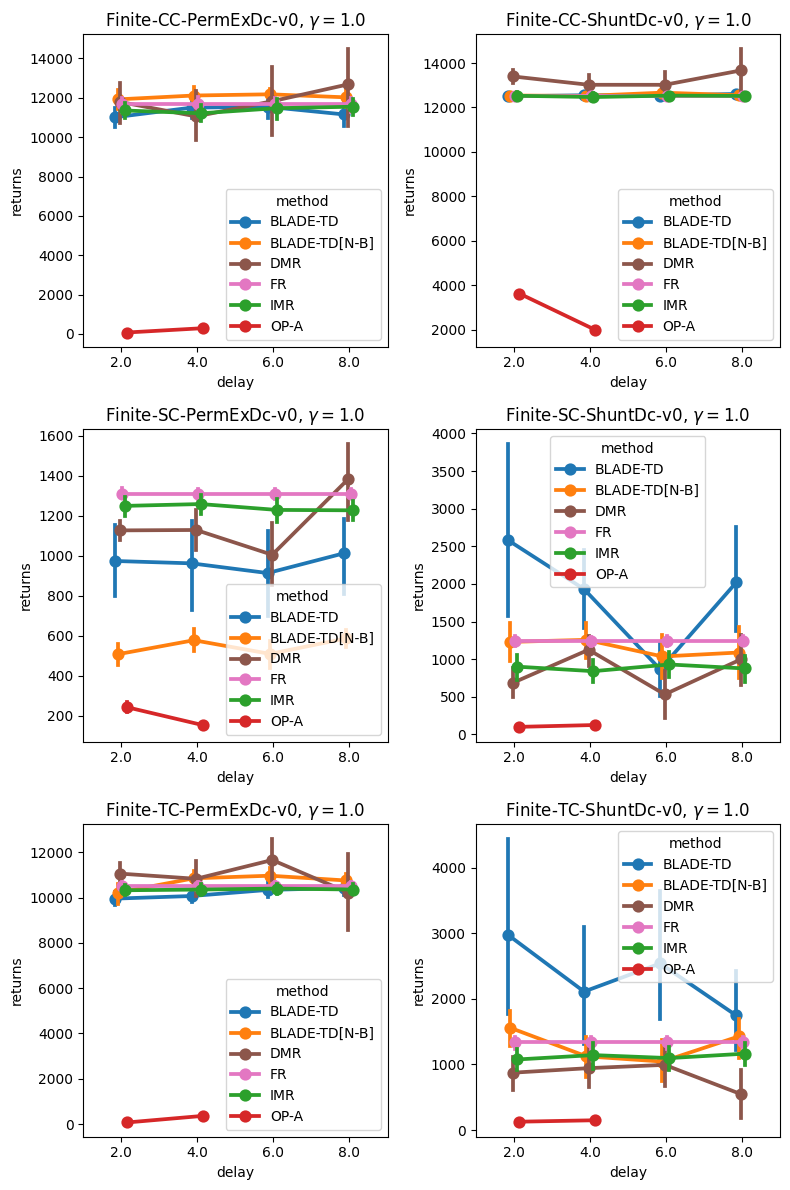

In [71]:
plot_return_ci(df_metrics, gamma=1.0, suffix="sarsa")

{'delay_type': 'clipped-poisson', 'delay_mu': 8.0}
{'delay_type': 'clipped-poisson', 'delay_mu': 4.0}
{'delay_type': 'clipped-poisson', 'delay_mu': 2.0}
{'delay_type': 'clipped-poisson', 'delay_mu': 6.0}


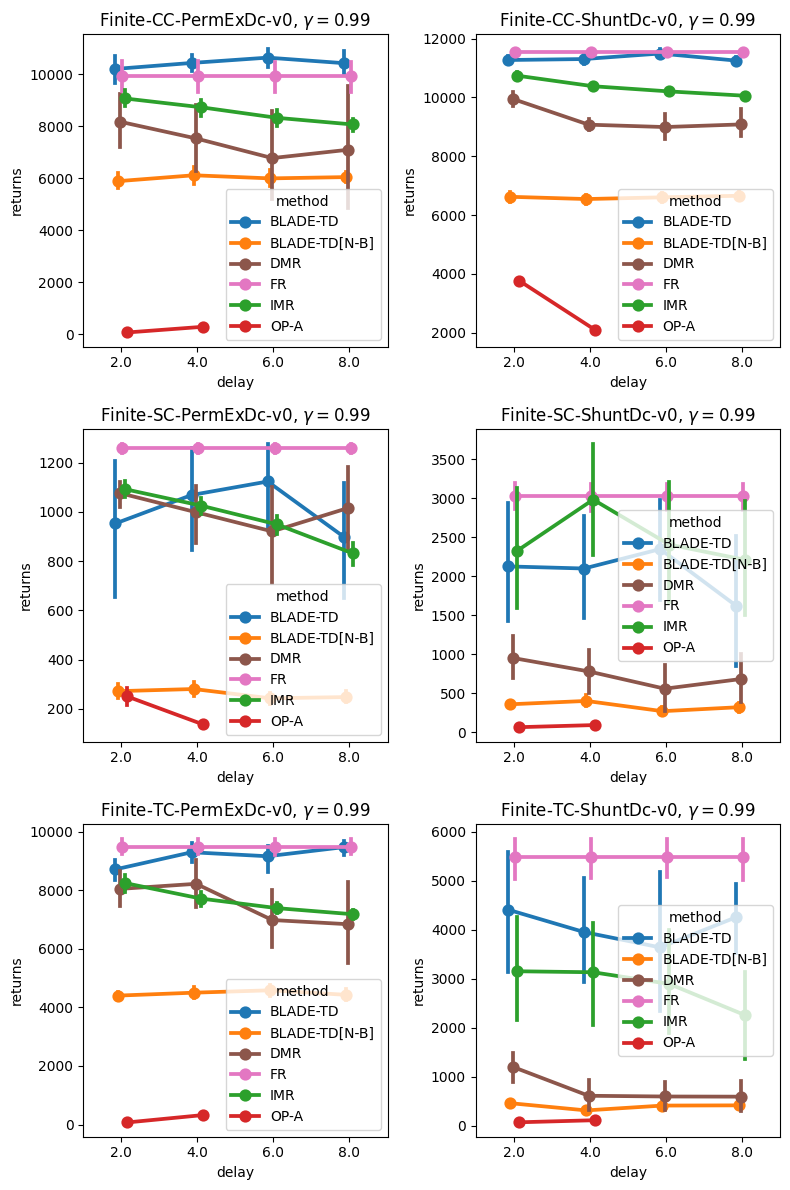

In [72]:
plot_return_ci(df_metrics, gamma=0.99, suffix="sarsa")

## Sample distributions

In [73]:
def plot_sample_dist(df_data, num_samples: int = 2):
    df_slice = max_episode_filter(df_data)
    df_slice = df_slice[["method", "meta", "returns"]]
    df_raw = copy.deepcopy(df_slice)
    methods = sorted(df_raw["method"].unique())

    fig, axes = plt.subplots(
        nrows=len(methods),
        ncols=num_samples,
        figsize=(4 * num_samples, 4 * len(methods)),
    )
    for row, method in enumerate(methods):
        df_algomethod = df_raw[(df_raw["method"] == method)]
        df_samples = df_algomethod.sample(n=num_samples)
        for idx in range(num_samples):
            ax = axes[row, idx]
            sample = df_samples.iloc[idx]
            miu = np.round(np.mean(sample["returns"]), decimals=2)
            sns.histplot(sample["returns"], ax=ax)
            title_template = " ".join(
                [
                    method,
                    "$\mu$ =",
                    str(miu),
                ]
            )
            ax.set_title(title_template)

<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
/var/folders/k4/24983l114vn7y9g2pg7d4yvc0000gn/T/ipykernel_7622/3230660266.py:23: SyntaxWarning: invalid escape sequence '\m'
  "$\mu$ =",


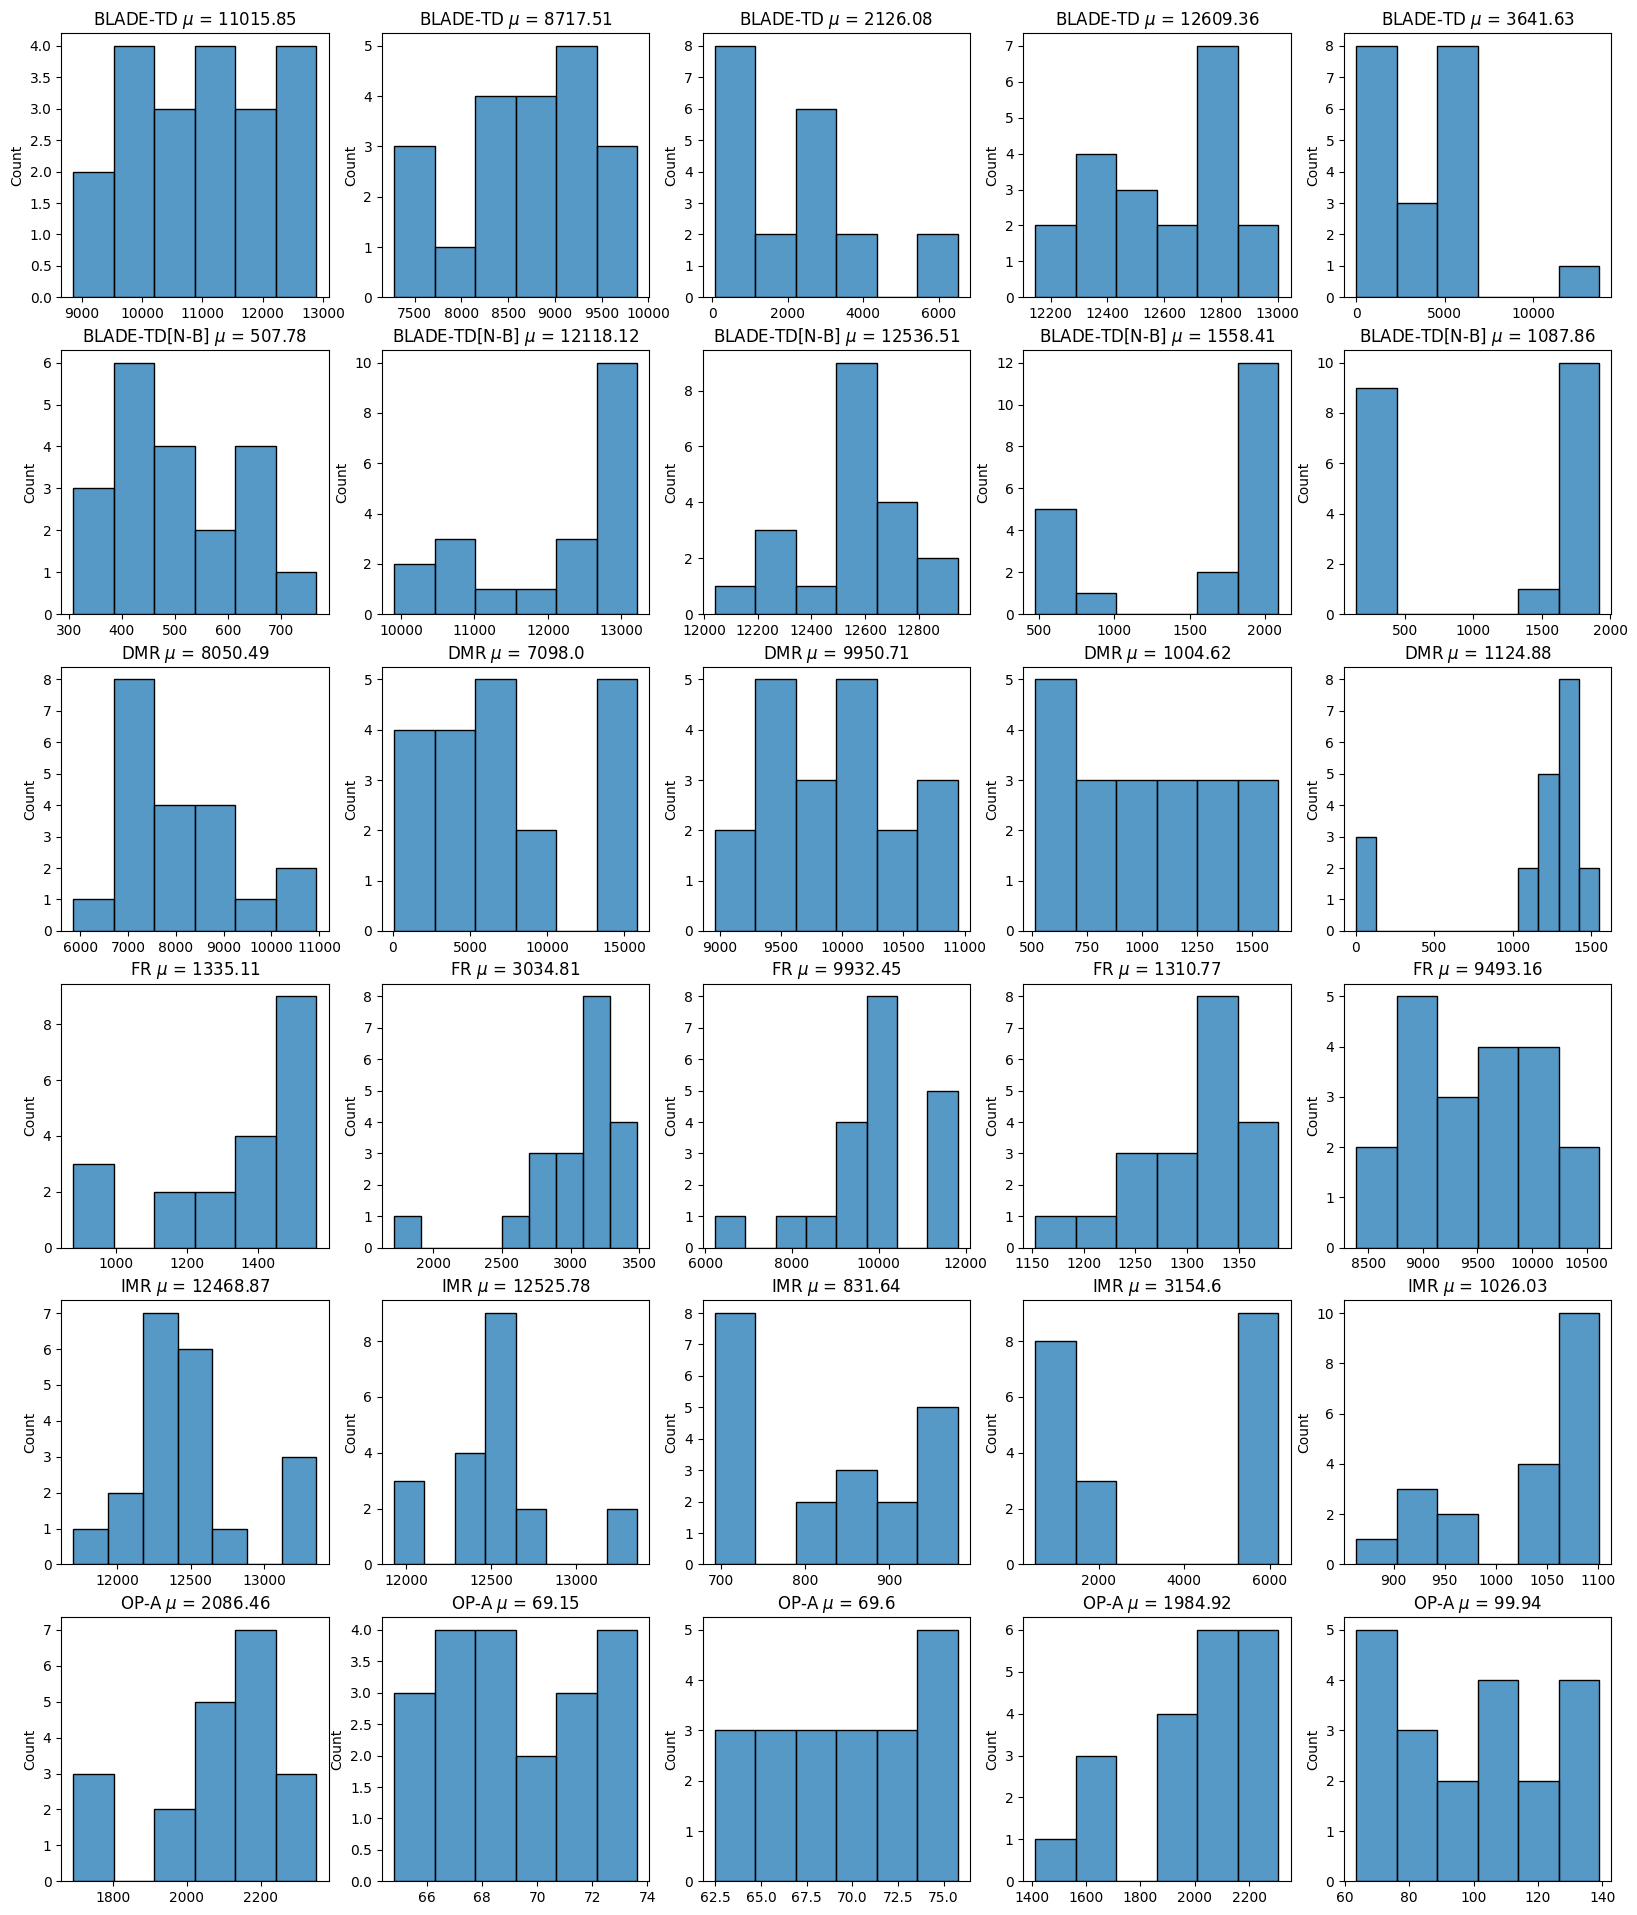

In [74]:
plot_sample_dist(df_metrics, 5)